# S&P 500 Equity+Options: Transaction Costs

This notebook stress-tests the best eligible allocation lineage under two
execution-cost conventions. The headline curve charges a percentage of
traded notional. The companion curve uses a per-share commission plus a flat
dollar half-spread. Both are validation-only diagnostics; the 2021 holdout
remains sealed.

**Learning objectives**

1. Carry one full-coverage allocation winner into a controlled cost sweep.
2. Distinguish one-way cost per traded notional from round-trip cost.
3. Compare percentage and per-share cost conventions without treating their
   x-axes as interchangeable.
4. Read point estimates together with block-bootstrap uncertainty.

**Book reference:** Chapter 18, Sections 18.2-18.5.

**Prerequisites:** `15_portfolio_management` and its registry-backed
allocation results. Signals form after Friday's close and execute at the next
available open, normally Monday. The configured universe uses current S&P 500
constituents and therefore retains survivorship bias.

In [1]:
"""S&P 500 Equity+Options: transaction-cost sensitivity."""

import json
import sqlite3
import time
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    set_backtest_costs_bps,
    set_backtest_costs_per_share,
    strategy_view,
)
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    model_source,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_cost_grid_bps,
    get_cost_grid_half_spread_usd,
    get_per_share_commission,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
LABEL = ""
MAX_SYMBOLS = 0
TOP_N_COMBOS = None

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_COMBOS is None:
    TOP_N_COMBOS = get_top_n_predictions(CASE_STUDY_ID, "cost_sensitivity")
if not LABEL:
    LABEL = bt_config.primary_label

COST_GRID_BPS = get_cost_grid_bps(CASE_STUDY_ID)
COST_GRID_HALF_SPREAD_USD = get_cost_grid_half_spread_usd(CASE_STUDY_ID)
PER_SHARE_COMMISSION = get_per_share_commission(CASE_STUDY_ID)
DEFAULT_ONE_WAY_BPS = bt_config.commission_bps + bt_config.slippage_bps

print(
    f"Case study: {CASE_STUDY_ID}; label: {LABEL}; selected lineages: {TOP_N_COMBOS}; "
    f"configured one-way cost: {DEFAULT_ONE_WAY_BPS:.1f} bps"
)

Case study: sp500_equity_option_analytics; label: fwd_ret_5d; selected lineages: 1; configured one-way cost: 6.5 bps


## 1. Advance the best eligible strategy carrier

The ranking compares the equal-weight baseline with the active alternative
allocators using validation Sharpe and maximum prediction coverage.
Historical rows from removed allocators cannot re-enter the cost stage.

In [4]:
active_allocators = {item["method"] for item in get_allocators(CASE_STUDY_ID)}
baseline_pool = resolve_best_backtest_runs(
    CASE_STUDY_ID, LABEL, split="validation", stage="signal", top_n=9999
)
allocation_pool = resolve_best_backtest_runs(
    CASE_STUDY_ID, LABEL, split="validation", stage="allocation", top_n=9999
)
candidate_pool = pl.concat([baseline_pool, allocation_pool], how="diagonal_relaxed").unique(
    "backtest_hash"
)
candidate_hashes = candidate_pool["prediction_hash"].unique().to_list()
if not candidate_hashes:
    raise RuntimeError("No full-coverage baseline or allocation candidates found")

Model labels come from prediction provenance rather than from free-form
strategy metadata.

In [5]:
with sqlite3.connect(REGISTRY_DB) as db:
    source_rows = db.execute(
        f"""
        SELECT p.prediction_hash, t.family, t.config_name
        FROM prediction_sets p
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.prediction_hash IN ({",".join("?" for _ in candidate_hashes)})
        """,
        candidate_hashes,
    ).fetchall()
source_by_hash = {
    prediction_hash: model_source(family, config_name)
    for prediction_hash, family, config_name in source_rows
}

The baseline is the equal-weight member of the candidate union. Alternative
allocation rows are eligible only when their method remains active in the
current case-study configuration.

In [6]:
eligible_rows = []
for row in candidate_pool.iter_rows(named=True):
    strategy = strategy_view(json.loads(row["spec_json"]))
    allocator = strategy.get("allocation", {}).get("method", "equal_weight")
    if allocator == "equal_weight" or allocator in active_allocators:
        eligible_rows.append(
            {
                **row,
                "source": source_by_hash[row["prediction_hash"]],
                "allocator": allocator,
                "top_k": strategy.get("signal", {}).get("top_k"),
            }
        )

if len(eligible_rows) < TOP_N_COMBOS:
    raise RuntimeError(
        f"Expected {TOP_N_COMBOS} eligible strategy lineages, found {len(eligible_rows)}"
    )

top_combos = pl.DataFrame(eligible_rows).sort("sharpe", descending=True).head(TOP_N_COMBOS)
winner = top_combos.row(0, named=True)
print(
    f"Selected {winner['source']} with {winner['allocator']} allocation, "
    f"top-{winner['top_k']}, validation Sharpe {winner['sharpe']:.3f}"
)

Selected deep_learning/nlinear with score_weighted allocation, top-10, validation Sharpe 1.186


The corrected primary-label carrier is NLinear with score weighting and ten
stocks. Its allocation-stage Sharpe is 1.186 at the configured 6.5 bps
one-way charge, equivalent to 13 bps for a buy-and-sell round trip.

In [7]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
print(
    f"Price support: {len(prices):,} rows across {prices['symbol'].n_unique()} historical symbols"
)

Price support: 505,922 rows across 614 historical symbols


## 2. Build the two cost surfaces

The percentage grid splits each one-way charge equally between commission
and slippage. The per-share grid fixes commission at $0.0035 per share and
varies a uniform half-spread. It omits a per-order commission floor and does
not estimate name-specific spreads, so it is an exploratory convention rather
than a second production-cost estimate.

In [8]:
base_specs = []
for combo in top_combos.iter_rows(named=True):
    prediction_hash = combo["prediction_hash"]
    base_spec = ensure_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        json.loads(combo["spec_json"]),
        prices=prices,
        prediction_hash=prediction_hash,
        initial_cash=bt_config.initial_cash,
    )
    base_specs.append((combo, prediction_hash, base_spec))

The percentage-cost surface divides each one-way charge equally between
commission and slippage.

In [9]:
plans = []
for combo, prediction_hash, base_spec in base_specs:
    for cost_bps in COST_GRID_BPS:
        spec = set_backtest_costs_bps(
            clone_backtest_spec(base_spec),
            commission_bps=cost_bps / 2,
            slippage_bps=cost_bps / 2,
        )
        spec["chapter"] = "ch18"
        plans.append(
            {
                "regime": "bps",
                "cost_value": float(cost_bps),
                "source": combo["source"],
                "allocator": combo["allocator"],
                "prediction_hash": prediction_hash,
                "spec": spec,
                "backtest_hash": backtest_hash_from_parts(prediction_hash, spec),
            }
        )

The companion surface keeps the per-share commission fixed while varying a
flat dollar half-spread.

In [10]:
for combo, prediction_hash, base_spec in base_specs:
    for half_spread_usd in COST_GRID_HALF_SPREAD_USD:
        spec = set_backtest_costs_per_share(
            clone_backtest_spec(base_spec),
            per_share=PER_SHARE_COMMISSION,
            default_half_spread_usd=half_spread_usd,
        )
        spec["chapter"] = "ch18"
        plans.append(
            {
                "regime": "per_share",
                "cost_value": float(half_spread_usd),
                "source": combo["source"],
                "allocator": combo["allocator"],
                "prediction_hash": prediction_hash,
                "spec": spec,
                "backtest_hash": backtest_hash_from_parts(prediction_hash, spec),
            }
        )

Planned hashes make the publication replay idempotent: completed points are
read from the registry and only missing points are computed.

In [11]:
with sqlite3.connect(REGISTRY_DB) as db:
    existing_hashes = {row[0] for row in db.execute("SELECT backtest_hash FROM backtest_runs")}

cached = sum(plan["backtest_hash"] in existing_hashes for plan in plans)
print(f"Planned {len(plans)} cost backtests; {cached} already complete")

Planned 17 cost backtests; 17 already complete


A production run fails if any planned point fails. Cached hashes are reused;
the final publication replay should not mutate the registry.

In [12]:
prediction_cache = {}
failures = []
started = time.monotonic()

In [13]:
for index, plan in enumerate(plans, start=1):
    if plan["backtest_hash"] in existing_hashes:
        continue
    prediction_hash = plan["prediction_hash"]
    if prediction_hash not in prediction_cache:
        prediction_cache[prediction_hash] = read_predictions(CASE_STUDY_ID, prediction_hash)
    try:
        result = run_backtest(
            CASE_STUDY_ID,
            prediction_hash,
            plan["spec"],
            prices=prices,
            predictions=prediction_cache[prediction_hash],
            label=LABEL,
            register=True,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
        )
        existing_hashes.add(plan["backtest_hash"])
        print(
            f"[{index}/{len(plans)}] {plan['regime']} cost={plan['cost_value']:.4g}: "
            f"Sharpe={result.metrics['sharpe']:.3f}",
            flush=True,
        )
    except Exception as exc:  # noqa: BLE001
        failures.append(f"{plan['backtest_hash']} {plan['regime']}: {exc}")

In [14]:
if failures:
    raise RuntimeError("Cost-sweep failures:\n" + "\n".join(failures))
print(f"Cost surfaces complete in {(time.monotonic() - started):.1f}s")

Cost surfaces complete in 0.0s


## 3. Compare the selected lineage

The query is keyed by the hashes planned above. Rows from other labels,
prediction lineages, removed allocators, and earlier sweeps cannot enter the
charts or takeaways.

In [15]:
plan_meta = pl.DataFrame(
    [
        {
            "backtest_hash": plan["backtest_hash"],
            "regime": plan["regime"],
            "cost_value": plan["cost_value"],
            "source": plan["source"],
            "allocator": plan["allocator"],
        }
        for plan in plans
    ]
)
placeholders = ",".join("?" for _ in plans)
with sqlite3.connect(REGISTRY_DB) as db:
    metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.stage, bm.sharpe, bm.sharpe_ci95_lo,
               bm.sharpe_ci95_hi, bm.max_drawdown, bm.num_trades
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({placeholders})
        """,
        connection=db,
        execute_options={"parameters": [plan["backtest_hash"] for plan in plans]},
    )

In [16]:
cost_results = plan_meta.join(metrics, on="backtest_hash", how="inner")
if len(cost_results) != len(plans):
    raise RuntimeError(f"Expected {len(plans)} cost rows, found {len(cost_results)}")
if cost_results.filter(pl.col("stage") != "cost_sensitivity").height:
    raise RuntimeError("A planned cost hash was registered under the wrong stage")
print(f"Loaded all {len(cost_results)} planned cost results")

Loaded all 17 planned cost results


The percentage-cost point estimate decays smoothly from 1.248 at zero cost
to 1.153 at 10 bps, 1.105 at 15 bps, and 0.769 at 50 bps. The interval's
lower bound first crosses zero at 10 bps; bootstrap noise makes the lower
bound non-monotonic beyond that point. The stress curve therefore supports a
gradual-decay conclusion, not precision about the true net Sharpe.

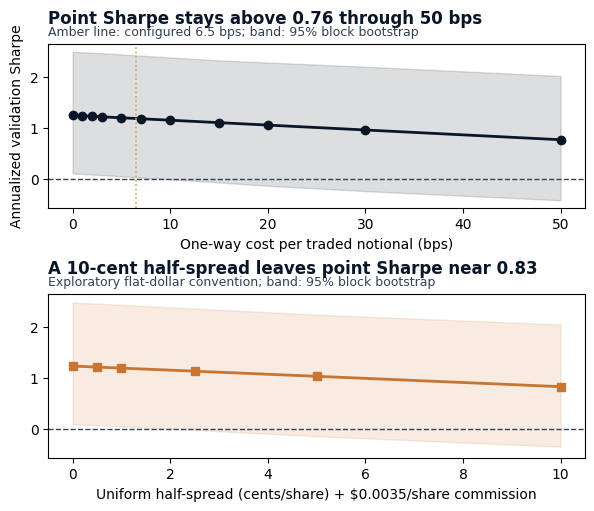

In [17]:
bps_results = cost_results.filter(pl.col("regime") == "bps").sort("cost_value")
per_share_results = cost_results.filter(pl.col("regime") == "per_share").sort("cost_value")

fig, (ax_bps, ax_ps) = plt.subplots(
    2, 1, figsize=FIGSIZE["dual_v"], sharey=True, constrained_layout=True
)

ax_bps.plot(
    bps_results["cost_value"],
    bps_results["sharpe"],
    marker="o",
    color=COLORS["blue"],
    linewidth=2,
)
ax_bps.fill_between(
    bps_results["cost_value"],
    bps_results["sharpe_ci95_lo"],
    bps_results["sharpe_ci95_hi"],
    color=COLORS["blue"],
    alpha=0.14,
)
ax_bps.axhline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax_bps.axvline(DEFAULT_ONE_WAY_BPS, color=COLORS["amber"], linewidth=1.2, linestyle=":")
ax_bps.set_xlabel("One-way cost per traded notional (bps)")
ax_bps.set_ylabel("Annualized validation Sharpe")
add_message_title(
    ax_bps,
    "Point Sharpe stays above 0.76 through 50 bps",
    f"Amber line: configured {DEFAULT_ONE_WAY_BPS:.1f} bps; band: 95% block bootstrap",
)

ax_ps.plot(
    per_share_results["cost_value"] * 100,
    per_share_results["sharpe"],
    marker="s",
    color=COLORS["copper"],
    linewidth=2,
)
ax_ps.fill_between(
    per_share_results["cost_value"] * 100,
    per_share_results["sharpe_ci95_lo"],
    per_share_results["sharpe_ci95_hi"],
    color=COLORS["copper"],
    alpha=0.14,
)
ax_ps.axhline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax_ps.set_xlabel(
    f"Uniform half-spread (cents/share) + ${PER_SHARE_COMMISSION:.4f}/share commission"
)
add_message_title(
    ax_ps,
    "A 10-cent half-spread leaves point Sharpe near 0.83",
    "Exploratory flat-dollar convention; band: 95% block bootstrap",
)

fig.show()

## Key takeaways

1. Cost selection is validation-only and carries the eligible NLinear,
   score-weighted, top-ten lineage forward without consulting the holdout.
2. The configured 6.5 bps one-way charge is equivalent to 13 bps round trip.
   Its allocation-stage Sharpe of 1.186 lies between the 5 bps result of
   1.200 and the 7 bps result of 1.181.
3. Percentage-cost point Sharpe declines to 1.153 at 10 bps, 1.105 at 15
   bps, and 0.769 at 50 bps. The bootstrap lower bound first crosses zero at
   10 bps, which limits confidence in the exact net level.
4. Under the exploratory per-share convention, point Sharpe moves from 1.234
   with commission only to 1.194 at a one-cent half-spread and 0.829 at ten
   cents. Flat dollar spreads on split-adjusted historical prices are not a
   substitute for name-level execution data.
5. The cost curve preserves the validation verdict across the grid, but it
   does not establish out-of-sample efficacy.

**Next:** `17_risk_management` tests risk overlays on the same eligible
validation lineage. See Chapter 19 for the risk-control framework.